http://www.ritchieng.com/machine-learning-project-customer-segments/

In [23]:
# Import Helper Libraries
import data_utils
# Reload Tweaked/Edited Helper Libraries 
import importlib
importlib.reload(data_utils)
#
from inspect import getsourcelines
#
import pandas as pd
import numpy as np
from tensorflow.contrib import keras
# Viz
%matplotlib inline
import matplotlib
matplotlib.style.use('ggplot')
from matplotlib import pyplot as plt

In [2]:
model = keras.models.load_model("2017-06-20__Keras")

In [20]:
x_train, y_train, x_valid, y_valid, x_test, y_test = data_utils.get_data(
    tr='rec', 
    bins=0, 
    threshold=2,
    fnorm='fn11',
    from_redshift=False,
    verbose=False)

Retrieving saved query data.
Reciprocating!
vod_v1 59
vod_v2 59
vod_acc 100
nxt_v1 159
nxt_v2 143
nxt_acc 217
num_vol_losses 15
pmt_pct_days_paid 120902
num_pmts 42
pct_ppv1 29271
num_invol_fail 65
vod_lst_30days 31
vod_lst_30to60days 31
vod_lst_60to90days 31
nxt_view_ep_lst_90days 127
nxt_view_ep_lst_30days 91
nxt_lst_30to60days 84
nxt_lst_60to90days 70
num_strms_vshp_all 4076
vod_num_strms 3884
num_nc_em_rcvd_1st_60days 24
overall_num_device_types 18
num_strms_vshp_net_orig 1168
num_strms_vshp_ring 1838
avg_rebuf_ratio_lst_30days 6064
avg_rebuf_ratio_lst_60days 5950
avg_rebuf_ratio_lst_90days 5999
Tranform Complete!
Beginning rescale...
Scaling Complete!


In [21]:
x = x_train.append(x_valid).append(x_test)
y = y_train.append(y_valid).append(y_test)

In [24]:
#==============================================
# Choose x_cols
#==============================================
#features = varnames('exl5','vod_pos','nxt_pos','months')
features = data_utils.varnames('exl4','vod_pos','nxt_pos','months')
#features = exl5 + vod_pos + nxt_pos + b4
#features = varnames('exl5','vod30','vod3060','nxt30','nxt3060','months','b4')

xx = x_valid.loc[:, features].values
yy = y_valid.loc[:].values


# Data Shape
n = xx.shape[0]
n_features = xx.shape[1]
n_classes  = yy.shape[1]
    

print('Chosen Inputs: ', x.loc[:, features].columns, '\n')
print('Event: ', 'CHURN')  # y_cols deleted at one pont...
print('Num Classes: ', n_classes)
print('X Shape: ', xx.shape)


Chosen Inputs:  Index(['apr', 'aug', 'dec', 'feb', 'jan', 'jul', 'jun', 'mar', 'may',
       'no_view_90days_flag', 'nov', 'num_vol_losses', 'nxt_lst_30to60days',
       'nxt_lst_60to90days', 'nxt_view_ep_lst_30days', 'oct', 'pct_ppv1',
       'pmt_pct_days_paid', 'sep', 'vod_lst_30days', 'vod_lst_30to60days',
       'vod_lst_60to90days'],
      dtype='object') 

Event:  CHURN
Num Classes:  1
X Shape:  (88950, 22)


In [28]:
y_pred =  model.predict(xx, batch_size=1024, verbose=True)

88950/88950 [==============================] - 0s     


In [29]:
y_actual = yy

In [30]:
# 1. Order (y_pred, churn=y_valid (or y_test)) by y_pred
sortIndex      =  np.argsort(y_pred[:,0])
sortIndex      =  sortIndex[::-1]
y_pred_sorted  =  y_pred[sortIndex,0]
y_sorted       =  y_actual[sortIndex,0]

# 2. Break y_pred and churn arrays into deciles 
#    -- since arrays are same length, np.array_split() splits them
#       into same-sized groups (all equal if possible)
y_pred_deciles = np.array_split(y_pred_sorted, 10)
y_deciles      = np.array_split(y_sorted, 10)


# 3. Record decile properties 
# - Population size for each decile
decile = np.linspace(1,10,10)
decile_size = np.array([len(decile) 
                        for decile in y_pred_deciles])
# - Number of actual churners in each decile
num_churners = np.array([sum(decile) 
                         for decile in y_deciles])
# - Churn Rate (churners/popSize)
churn_rate = np.array([round(100*n_churn/decile_size[i],1)
                       for i,n_churn in enumerate(num_churners)])
# - Number of All Churners
all_churners = np.repeat(np.sum(num_churners), 10)
# - Decile's Churner Stock:  num_churners / all_churners
proportion_of_churn = np.array([round(100*n_churn/all_churners[0],2) 
                          for n_churn in num_churners])
# - Cumulative sum of Churner Stock
cum_prop = np.cumsum(proportion_of_churn)
# - Cumulative sum of Churner Stock if Deciles were randomized groups
cum_control = np.linspace(10,100,10)

# Generate Pandas DataFrame
churnTable = pd.DataFrame({
    'decile': decile,
    'size': decile_size,
    'num_churn': num_churners,
    'churn_rate': churn_rate,
    'all_churn': all_churners,
    'proportion_of_churn': proportion_of_churn,
    'cum_prop': cum_prop,
    'cum_control': cum_control
})
churnTable=churnTable[['decile','size','num_churn','churn_rate','all_churn','proportion_of_churn','cum_prop','cum_control']]

In [31]:
churnTable

,decile,size,num_churn,churn_rate,all_churn,proportion_of_churn,cum_prop,cum_control
0,1.0,8895,2315,26.0,6379,36.29,36.29,10.0
1,2.0,8895,986,11.1,6379,15.46,51.75,20.0
2,3.0,8895,796,8.9,6379,12.48,64.23,30.0
3,4.0,8895,556,6.3,6379,8.72,72.95,40.0
4,5.0,8895,436,4.9,6379,6.83,79.78,50.0
5,6.0,8895,390,4.4,6379,6.11,85.89,60.0
6,7.0,8895,317,3.6,6379,4.97,90.86,70.0
7,8.0,8895,254,2.9,6379,3.98,94.84,80.0
8,9.0,8895,191,2.1,6379,2.99,97.83,90.0
9,10.0,8895,138,1.6,6379,2.16,99.99,100.0


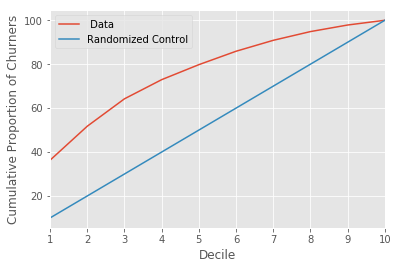

In [32]:
#plt.plot(churnTable['cum_stock'])
#plt.plot(churnTable['cum_stock_control'])
#churnTable['cum_prop'].plot()
#churnTable['cum_control'].plot()
fig = churnTable.plot(x='decile',y=['cum_prop','cum_control'])
fig.set_xlabel('Decile')
fig.set_ylabel('Cumulative Proportion of Churners')
fig.legend(labels=[' Data', 'Randomized Control'])

In [33]:
df = x.loc[sortIndex,features]

In [35]:
df['churn'] = y_sorted
df['churn_pred'] = y_pred_sorted
df['decile'] = np.concatenate([np.repeat(i+1, len(df)/10) for i in range(10)])
df['group'] = np.array([1 if dec <= 2 else 0 for dec in df['decile']])

In [184]:
# Get the means 
m_g0 = df[df.group==0].describe().loc['mean', :]
m_g1 = df[df.group==1].describe().loc['mean', :]


# Append means to the samples' data
#samples_bar = samples.append(mean_data)

# Construct indices
samples_bar.index = indices + ['mean']

# Plot bar plot
samples_bar.plot(kind='bar', figsize=(14,8))


In [227]:
pd.DataFrame( {"m_g0": m_g0.values, "m_g1": m_g1.values}, index=m_g0.index )
#help(pd.DataFrame)

,m_g0,m_g1
apr,-0.876644,-0.876335
aug,-0.730382,-0.733558
dec,-0.834767,-0.834176
feb,-0.855200,-0.863182
jan,-0.881759,-0.880944
jul,-0.756239,-0.751546
jun,-0.837521,-0.841934
mar,-0.923412,-0.920180
may,-0.870320,-0.865205
no_view_90days_flag,-0.881563,-0.880382
